In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
import cvxpy as cp
import riskfolio as rp
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

# File paths for NIFTY 200 stock data
closing_price_file = "/Users/veronica/Desktop/Aryan/Sem 2 2025 - 2026/FRM/FRM Project/Portfolio-Optimization--main/PX_LAST_Static.xlsx"
market_cap_file = '/Users/veronica/Desktop/Aryan/Sem 2 2025 - 2026/FRM/FRM Project/Portfolio-Optimization--main/CUR_MKT_CAP_Static.xlsx'
volume_file = '/Users/veronica/Desktop/Aryan/Sem 2 2025 - 2026/FRM/FRM Project/Portfolio-Optimization--main/PX_VOLUME_Static.xlsx'
ticker_data_file = '/Users/veronica/Desktop/Aryan/Sem 2 2025 - 2026/FRM/FRM Project/Portfolio-Optimization--main/FRM_MISC_PX_Last.xlsx'  # Added from draft6

# Load NIFTY 200 stock data
try:
    prices = pd.read_excel(closing_price_file, index_col=0)
    market_caps = pd.read_excel(market_cap_file, index_col=0)
    volumes = pd.read_excel(volume_file, index_col=0)
except Exception as e:
    print(f"Error loading NIFTY 200 stock data: {e}")
    raise

# Convert index to datetime for NIFTY 200 data
try:
    prices.index = pd.to_datetime(prices.index, format='%m/%d/%Y', errors='coerce')
    market_caps.index = pd.to_datetime(market_caps.index, format='%m/%d/%Y', errors='coerce')
    volumes.index = pd.to_datetime(volumes.index, format='%m/%d/%Y', errors='coerce')
except Exception as e:
    print(f"Error converting index to datetime for NIFTY 200 data: {e}")
    raise

# Drop invalid dates (NaT) in NIFTY 200 data
if prices.index.isna().any():
    print("Warning: Some dates could not be parsed in NIFTY 200 data. Dropping invalid dates.")
    prices = prices[prices.index.notna()]
    market_caps = market_caps[market_caps.index.notna()]
    volumes = volumes[volumes.index.notna()]

# Sort indices and align columns for NIFTY 200 data
prices = prices.sort_index()
market_caps = market_caps.sort_index().reindex(columns=prices.columns)
volumes = volumes.sort_index().reindex(columns=prices.columns)

# Check for missing data in NIFTY 200 data and forward-fill
if prices.isna().any().any() or market_caps.isna().any().any() or volumes.isna().any().any():
    print("Warning: Missing data detected in NIFTY 200 data. Filling with forward fill.")
    prices = prices.ffill()
    market_caps = market_caps.ffill()
    volumes = volumes.ffill()

# Load additional ticker data (India VIX, sector indices, etc.) directly from Excel (from draft6)
try:
    ticker_data = pd.read_excel(ticker_data_file)
except Exception as e:
    print(f"Error loading ticker data: {e}")
    raise

# Ensure the 'Dates' column is present and set as the index
if 'Dates' not in ticker_data.columns:
    print("Error: 'Dates' column not found in ticker data.")
    raise

# Convert 'Dates' to datetime
try:
    ticker_data['Dates'] = pd.to_datetime(ticker_data['Dates'], format='%Y-%m-%d', errors='coerce')
    ticker_data.set_index('Dates', inplace=True)
except Exception as e:
    print(f"Error converting 'Dates' to datetime in ticker data: {e}")
    raise

# Drop invalid dates (NaT) in ticker data
if ticker_data.index.isna().any():
    print("Warning: Some dates could not be parsed in ticker data. Dropping invalid dates.")
    ticker_data = ticker_data[ticker_data.index.notna()]

# Clean ticker data (from draft6)
# Remove duplicate column 'NSEMET Index.1'
if 'NSEMET Index.1' in ticker_data.columns:
    ticker_data = ticker_data.drop(columns=['NSEMET Index.1'])
    print("Dropped duplicate column 'NSEMET Index.1'.")

# Drop 'INQGGDPY Index' as it's constant and not useful
if 'INQGGDPY Index' in ticker_data.columns:
    ticker_data = ticker_data.drop(columns=['INQGGDPY Index'])
    print("Dropped 'INQGGDPY Index' as it is constant.")

# Forward-fill missing values in ticker data
if ticker_data.isna().any().any():
    print("Warning: Missing data detected in ticker data. Filling with forward fill.")
    ticker_data = ticker_data.ffill()

# Align ticker data dates with NIFTY 200 data
common_dates = prices.index.intersection(ticker_data.index)
prices = prices.loc[common_dates]
market_caps = market_caps.loc[common_dates]
volumes = volumes.loc[common_dates]
ticker_data = ticker_data.loc[common_dates]

# Debug: Inspect the data
print("NIFTY 200 stock data loaded successfully.")
print(f"Index type (NIFTY 200): {type(prices.index)}")
print(f"First few index values (NIFTY 200): {prices.index[:5]}")
print(f"Date range (NIFTY 200): {prices.index[0]} to {prices.index[-1]}")
print(f"Number of stocks (NIFTY 200): {len(prices.columns)}")

print("\nTicker data loaded successfully.")
print(f"Index type (Ticker data): {type(ticker_data.index)}")
print(f"First few index values (Ticker data): {ticker_data.index[:5]}")
print(f"Date range (Ticker data): {ticker_data.index[0]} to {ticker_data.index[-1]}")
print(f"Ticker data columns: {ticker_data.columns.tolist()}")

Dropped duplicate column 'NSEMET Index.1'.
Dropped 'INQGGDPY Index' as it is constant.
NIFTY 200 stock data loaded successfully.
Index type (NIFTY 200): <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
First few index values (NIFTY 200): DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-05', '2015-01-06',
               '2015-01-07'],
              dtype='datetime64[ns]', freq=None)
Date range (NIFTY 200): 2015-01-01 00:00:00 to 2025-03-24 00:00:00
Number of stocks (NIFTY 200): 153

Ticker data loaded successfully.
Index type (Ticker data): <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
First few index values (Ticker data): DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-05', '2015-01-06',
               '2015-01-07'],
              dtype='datetime64[ns]', freq=None)
Date range (Ticker data): 2015-01-01 00:00:00 to 2025-03-24 00:00:00
Ticker data columns: ['INVIXN Index', 'NSEBANK Index', 'NSEIT Index', 'NSEAUTO Index', 'NSEPHRM Index', 'NSEFMCG Index', 'NSEMET Index'

In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Compute daily returns
returns = np.log(prices / prices.shift(1)).dropna()

# 1. Market Return (Nifty 200 index return)
market_weights = market_caps.div(market_caps.sum(axis=1), axis=0)
market_returns = (returns * market_weights).sum(axis=1)

# 2. Long-Term Momentum (63-day past return)
momentum_63d = np.log(prices / prices.shift(63)).dropna()

# 3. Medium-Term Momentum (21-day past return)
momentum_21d = np.log(prices / prices.shift(21)).dropna()

# 4. Mean Reversion (5-day past return, expecting reversal)
mean_reversion = np.log(prices / prices.shift(5)).dropna()

# 5. Market Momentum (21-day market return)
market_momentum = market_returns.rolling(window=21).sum().shift(1).dropna()

# 6. Volatility Trend (21-day volatility minus 63-day volatility)
volatility_21d = returns.rolling(window=21).std() * np.sqrt(252)
volatility_63d = returns.rolling(window=63).std() * np.sqrt(252)
volatility_trend = (volatility_21d - volatility_63d).dropna()

# 7. Market Trend (50-day vs. 200-day moving average of market returns)
market_prices = (market_returns + 1).cumprod()  # Convert returns to a price series
ma_50 = market_prices.rolling(window=50).mean()
ma_200 = market_prices.rolling(window=200).mean()
market_trend = ((ma_50 - ma_200) / ma_200).dropna()  # Relative difference
market_trend = (market_trend - market_trend.mean()) / market_trend.std()  # Normalize

# 8. Sector Momentum (Cluster stocks into sectors and compute average momentum)
momentum_21d_mean = momentum_21d.mean()
kmeans = KMeans(n_clusters=5, random_state=42)
sector_labels = kmeans.fit_predict(momentum_21d_mean.values.reshape(-1, 1))
sector_mapping = dict(zip(momentum_21d.columns, sector_labels))
sector_indices = [f'Sector {i}' for i in range(5)]
sector_momentum = pd.DataFrame(index=momentum_21d.index, columns=momentum_21d.columns)
for stock in momentum_21d.columns:
    sector = sector_labels[momentum_21d.columns.get_loc(stock)]
    sector_stocks = momentum_21d.columns[sector_labels == sector]
    sector_momentum[stock] = momentum_21d[sector_stocks].mean(axis=1)
sector_momentum = sector_momentum.dropna()

# 9. Liquidity (Turnover: Volume * Price / Market Cap, normalized by 21-day average)
liquidity = (volumes * prices) / market_caps
liquidity = (liquidity / liquidity.rolling(window=21).mean()).dropna()

# 10. Size (Log of Market Cap, normalized)
size = np.log(market_caps)
size = (size - size.mean()) / size.std()  # Normalize
size = size.dropna()

# 11. Market Volatility (21-day India VIX, normalized) - New from draft6
market_volatility = ticker_data['INVIXN Index'].rolling(window=21).mean().shift(1)
market_volatility = (market_volatility - market_volatility.mean()) / market_volatility.std()  # Normalize
market_volatility = market_volatility.dropna()

# 12. Interest Rate Trend (21-day change in GIND10YR, normalized) - New from draft6
interest_rate_trend = ticker_data['GIND10YR Index'].diff(21).shift(1)
interest_rate_trend = (interest_rate_trend - interest_rate_trend.mean()) / interest_rate_trend.std()  # Normalize
interest_rate_trend = interest_rate_trend.dropna()

# 13. Currency Trend (21-day USDINR return, normalized) - New from draft6
currency_trend = np.log(ticker_data['USDINR Curncy'] / ticker_data['USDINR Curncy'].shift(21)).shift(1)
currency_trend = (currency_trend - currency_trend.mean()) / currency_trend.std()  # Normalize
currency_trend = currency_trend.dropna()

# 14. Oil Momentum (21-day CL1 return, normalized) - New from draft6
oil_momentum = np.log(ticker_data['CL1 Comdty'] / ticker_data['CL1 Comdty'].shift(21)).shift(1)
oil_momentum = (oil_momentum - oil_momentum.mean()) / oil_momentum.std()  # Normalize
oil_momentum = oil_momentum.dropna()

# 15. Gold Momentum (21-day XAU return, normalized) - New from draft6
gold_momentum = np.log(ticker_data['XAU Curncy'] / ticker_data['XAU Curncy'].shift(21)).shift(1)
gold_momentum = (gold_momentum - gold_momentum.mean()) / gold_momentum.std()  # Normalize
gold_momentum = gold_momentum.dropna()

# Align all data to the same dates
common_dates = returns.index.intersection(momentum_63d.index).intersection(momentum_21d.index).intersection(mean_reversion.index).intersection(market_momentum.index).intersection(volatility_trend.index).intersection(market_trend.index).intersection(sector_momentum.index).intersection(liquidity.index).intersection(size.index).intersection(market_volatility.index).intersection(interest_rate_trend.index).intersection(currency_trend.index).intersection(oil_momentum.index).intersection(gold_momentum.index)
returns = returns.loc[common_dates]
market_returns = market_returns.loc[common_dates]
momentum_63d = momentum_63d.loc[common_dates]
momentum_21d = momentum_21d.loc[common_dates]
mean_reversion = mean_reversion.loc[common_dates]
market_momentum = market_momentum.loc[common_dates]
volatility_trend = volatility_trend.loc[common_dates]
market_trend = market_trend.loc[common_dates]
sector_momentum = sector_momentum.loc[common_dates]
liquidity = liquidity.loc[common_dates]
size = size.loc[common_dates]
market_volatility = market_volatility.loc[common_dates]
interest_rate_trend = interest_rate_trend.loc[common_dates]
currency_trend = currency_trend.loc[common_dates]
oil_momentum = oil_momentum.loc[common_dates]
gold_momentum = gold_momentum.loc[common_dates]

print("Factors computed successfully.")
print(f"Aligned date range: {common_dates[0]} to {common_dates[-1]}")

Factors computed successfully.
Aligned date range: 2015-10-21 00:00:00 to 2025-03-24 00:00:00


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


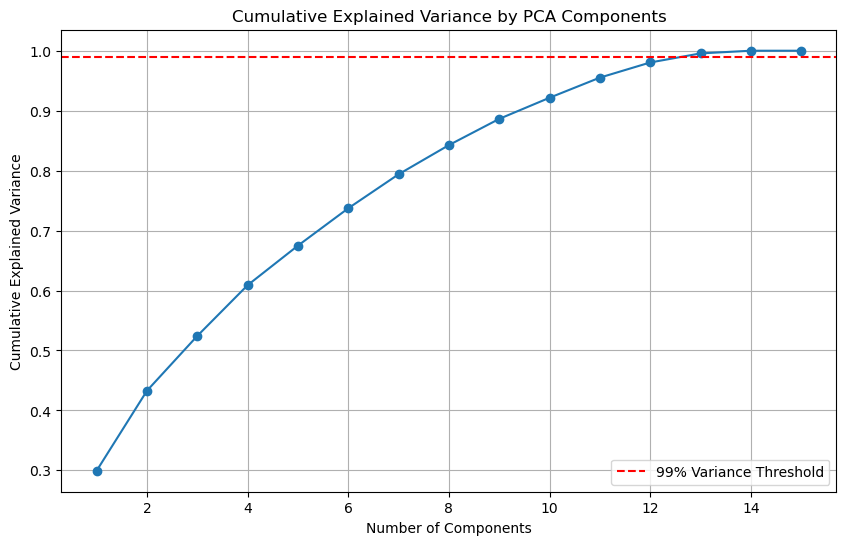

Number of PCA components to explain 99% of variance: 13

PCA Loadings (Contributions of Factors to Principal Components):
                          PC1       PC2       PC3       PC4       PC5  \
market               0.099259 -0.091800  0.639017 -0.067069  0.079580   
momentum_63d         0.325045  0.350964  0.045048 -0.022563  0.005757   
momentum_21d         0.450394 -0.080513  0.043424 -0.015584 -0.004317   
mean_reversion       0.257667 -0.135561  0.515613 -0.002969  0.052619   
market_momentum      0.428722 -0.098890 -0.094478  0.013257 -0.014442   
volatility_trend    -0.257374  0.233860  0.368750  0.190871 -0.010234   
market_trend         0.113688  0.572647  0.090087  0.139910 -0.024316   
sector_momentum      0.450394 -0.080513  0.043424 -0.015584 -0.004317   
liquidity           -0.005873 -0.072584 -0.078707  0.209124  0.925263   
size                 0.089009  0.411943  0.078300  0.240315  0.032894   
market_volatility   -0.109716 -0.411824  0.257752 -0.070624 -0.020356   
in

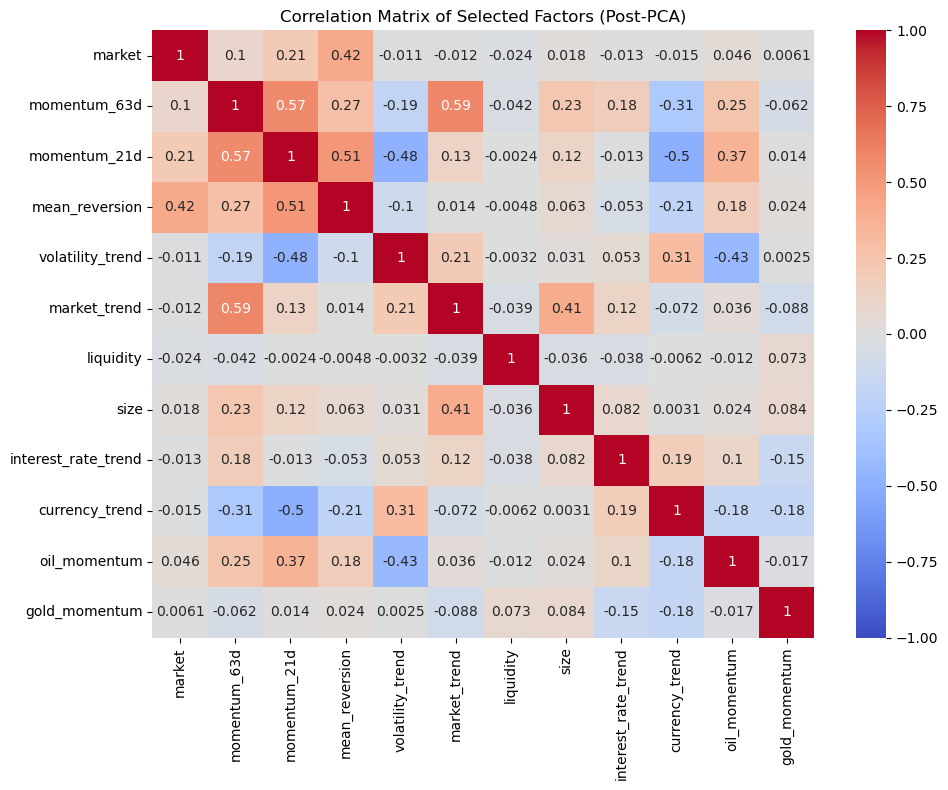


Highly correlated pairs (correlation > 0.8 or < -0.8) among selected factors:

No highly correlated pairs found among selected factors.

Factors computed successfully.
Aligned date range: 2015-10-21 00:00:00 to 2025-03-24 00:00:00
Number of final selected factors: 12


In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Collect all factors into a dictionary
all_factors = {
    'market': market_returns,
    'momentum_63d': momentum_63d,
    'momentum_21d': momentum_21d,
    'mean_reversion': mean_reversion,
    'market_momentum': market_momentum,
    'volatility_trend': volatility_trend,
    'market_trend': market_trend,
    'sector_momentum': sector_momentum,
    'liquidity': liquidity,
    'size': size,
    'market_volatility': market_volatility,
    'interest_rate_trend': interest_rate_trend,
    'currency_trend': currency_trend,
    'oil_momentum': oil_momentum,
    'gold_momentum': gold_momentum
}

# Prepare factors for PCA (convert to a DataFrame)
factors_df = pd.DataFrame({
    key: (value.mean(axis=1) if isinstance(value, pd.DataFrame) else value) for key, value in all_factors.items()
}).dropna()

# Standardize the factors
scaler = StandardScaler()
factors_scaled = scaler.fit_transform(factors_df)

# Apply PCA
pca = PCA()
pca.fit(factors_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.99, color='r', linestyle='--', label='99% Variance Threshold')  # Updated to 99%
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid()
plt.show()

# Determine the number of components to explain 99% of variance (Updated)
n_components = np.argmax(cumulative_variance >= 0.99) + 1
print(f"Number of PCA components to explain 99% of variance: {n_components}")

# Get the loadings (contributions of each factor to the principal components)
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(factors_df.columns))], index=factors_df.columns)
print("\nPCA Loadings (Contributions of Factors to Principal Components):")
print(loadings.iloc[:, :n_components])

# Identify the most impactful factors based on the loadings of the top components
important_factors = []
for i in range(n_components):
    pc_loadings = loadings[f'PC{i+1}'].abs()
    top_factor = pc_loadings.idxmax()
    important_factors.append(top_factor)
important_factors = list(set(important_factors))  # Remove duplicates
print(f"\nMost impactful factors based on PCA: {important_factors}")

# Filter the factors to keep only the most impactful ones
selected_factors = {key: value for key, value in all_factors.items() if key in important_factors}
print(f"\nSelected factors after PCA: {list(selected_factors.keys())}")

# Additional Step: Check for high correlations among the selected factors and remove redundant ones
# Compute correlation matrix for the selected factors
selected_factors_df = pd.DataFrame({
    key: (value.mean(axis=1) if isinstance(value, pd.DataFrame) else value) for key, value in selected_factors.items()
}).dropna()

selected_correlation_matrix = selected_factors_df.corr()

# Plot the correlation matrix for selected factors
plt.figure(figsize=(10, 8))
sns.heatmap(selected_correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix of Selected Factors (Post-PCA)')
plt.tight_layout()
plt.show()

# Identify highly correlated pairs (correlation > 0.8 or < -0.8)
print("\nHighly correlated pairs (correlation > 0.8 or < -0.8) among selected factors:")
high_correlations = []
threshold = 0.8
for i in range(len(selected_correlation_matrix.columns)):
    for j in range(i + 1, len(selected_correlation_matrix.columns)):
        corr = selected_correlation_matrix.iloc[i, j]
        if abs(corr) > threshold:
            high_correlations.append((selected_correlation_matrix.columns[i], selected_correlation_matrix.columns[j], corr))
            print(f"{selected_correlation_matrix.columns[i]} and {selected_correlation_matrix.columns[j]}: {corr:.3f}")

# Remove one feature from each highly correlated pair
# We'll keep the feature that appeared in the earlier principal component
if high_correlations:
    to_remove = set()
    for factor1, factor2, corr in high_correlations:
        # Find which factor appears in an earlier PC
        pc1 = min([i for i in range(n_components) if loadings[f'PC{i+1}'].abs().idxmax() == factor1], default=n_components)
        pc2 = min([i for i in range(n_components) if loadings[f'PC{i+1}'].abs().idxmax() == factor2], default=n_components)
        # Remove the factor that appears in the later PC
        if pc1 < pc2:
            to_remove.add(factor2)
        else:
            to_remove.add(factor1)

    # Update selected factors by removing the redundant ones
    final_selected_factors = {key: value for key, value in selected_factors.items() if key not in to_remove}
    print(f"\nFactors removed due to high correlation: {to_remove}")
    print(f"Final selected factors after removing high correlations: {list(final_selected_factors.keys())}")
else:
    print("\nNo highly correlated pairs found among selected factors.")
    final_selected_factors = selected_factors

# Debug: Inspect the aligned data
print("\nFactors computed successfully.")
print(f"Aligned date range: {common_dates[0]} to {common_dates[-1]}")
print(f"Number of final selected factors: {len(final_selected_factors)}")

In [4]:
from datetime import timedelta

# Define split dates (same as original code)
train_end = pd.to_datetime('2020-06-30')
val_end = pd.to_datetime('2021-12-31')
test_start = pd.to_datetime('2022-01-01')
test_end = pd.to_datetime('2025-03-18')

# Adjust split dates to the nearest available dates in the data
train_end = returns.index[returns.index <= train_end][-1] if any(returns.index <= train_end) else returns.index[0]
val_end = returns.index[returns.index <= val_end][-1] if any(returns.index <= val_end) else returns.index[-1]
test_start = returns.index[returns.index >= test_start][0] if any(returns.index >= test_start) else returns.index[-1]
test_end = returns.index[returns.index <= test_end][-1] if any(returns.index <= test_end) else returns.index[-1]

# Split returns
train_returns = returns.truncate(before=returns.index[0], after=train_end)
val_returns = returns.truncate(before=train_end + timedelta(days=1), after=val_end)
test_returns = returns.truncate(before=test_start, after=test_end)

# Split factors (using final_selected_factors from the previous block)
train_factors = {key: value.truncate(before=value.index[0], after=train_end) for key, value in final_selected_factors.items()}
val_factors = {key: value.truncate(before=train_end + timedelta(days=1), after=val_end) for key, value in final_selected_factors.items()}
test_factors = {key: value.truncate(before=test_start, after=test_end) for key, value in final_selected_factors.items()}

# Debug: Inspect the split
print("Data split completed.")
print(f"Training: {train_returns.index[0]} to {train_returns.index[-1]}")
print(f"Validation: {val_returns.index[0]} to {val_returns.index[-1]}")
print(f"Testing: {test_returns.index[0]} to {test_returns.index[-1]}")
print(f"Selected factors used: {list(final_selected_factors.keys())}")

Data split completed.
Training: 2015-10-21 00:00:00 to 2020-06-30 00:00:00
Validation: 2020-07-01 00:00:00 to 2021-12-31 00:00:00
Testing: 2022-01-03 00:00:00 to 2025-03-18 00:00:00
Selected factors used: ['market', 'momentum_63d', 'momentum_21d', 'mean_reversion', 'volatility_trend', 'market_trend', 'liquidity', 'size', 'interest_rate_trend', 'currency_trend', 'oil_momentum', 'gold_momentum']


In [5]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import pandas as pd
from datetime import timedelta

# Add new factor: Volatility Momentum (21-day return of India VIX, normalized)
volatility_momentum = np.log(ticker_data['INVIXN Index'] / ticker_data['INVIXN Index'].shift(21)).shift(1)
volatility_momentum = (volatility_momentum - volatility_momentum.mean()) / volatility_momentum.std()  # Normalize
volatility_momentum = volatility_momentum.dropna()

# Add to final_selected_factors if not already present
if 'volatility_momentum' not in final_selected_factors:
    final_selected_factors['volatility_momentum'] = volatility_momentum

# Align all factors with returns
common_dates = returns.index
for factor_name, factor_data in final_selected_factors.items():
    common_dates = common_dates.intersection(factor_data.index if isinstance(factor_data, pd.Series) else factor_data.index)
for factor_name, factor_data in final_selected_factors.items():
    final_selected_factors[factor_name] = factor_data.reindex(common_dates, method='ffill')
returns = returns.loc[common_dates]

# Split returns and factors with updated data
train_end = pd.to_datetime('2020-06-30')
val_end = pd.to_datetime('2021-12-31')
test_start = pd.to_datetime('2022-01-01')
# Set test_end to the last date in the aligned data
test_end = returns.index[-1]

train_end = returns.index[returns.index <= train_end][-1] if any(returns.index <= train_end) else returns.index[0]
val_end = returns.index[returns.index <= val_end][-1] if any(returns.index <= val_end) else returns.index[-1]
test_start = returns.index[returns.index >= test_start][0] if any(returns.index >= test_start) else returns.index[-1]
test_end = returns.index[returns.index <= test_end][-1] if any(returns.index <= test_end) else returns.index[-1]

train_returns = returns.truncate(before=returns.index[0], after=train_end)
val_returns = returns.truncate(before=train_end + timedelta(days=1), after=val_end)
test_returns = returns.truncate(before=test_start, after=test_end)

train_factors = {key: value.truncate(before=value.index[0], after=train_end) for key, value in final_selected_factors.items()}
val_factors = {key: value.truncate(before=train_end + timedelta(days=1), after=val_end) for key, value in final_selected_factors.items()}
test_factors = {key: value.truncate(before=test_start, after=test_end) for key, value in final_selected_factors.items()}

def run_regression(stock_returns_train, factors_train, stock_returns_pred, factors_pred, lookback=63, horizon=21, alpha=100.0):
    n_stocks = stock_returns_train.shape[1]
    n_days_train = len(stock_returns_train)
    n_days_pred = len(stock_returns_pred)
    
    if n_days_train < lookback:
        raise ValueError(f"Lookback period ({lookback}) is larger than the training data length ({n_days_train}).")
    if n_days_pred < horizon:
        raise ValueError(f"Horizon ({horizon}) is larger than the prediction data length ({n_days_pred}).")
    
    # Prediction dates should start after lookback days to ensure we have enough data
    pred_dates = stock_returns_pred.index[lookback:n_days_pred - horizon + 1]
    if len(pred_dates) == 0:
        raise ValueError("Not enough data to form prediction dates after accounting for lookback and horizon.")
    
    predictions = pd.DataFrame(np.zeros((len(pred_dates), n_stocks)), index=pred_dates, columns=stock_returns_train.columns)
    residuals = pd.DataFrame(np.zeros((len(pred_dates), n_stocks)), index=pred_dates, columns=stock_returns_train.columns)
    
    scaler = StandardScaler()
    
    # Time decay weights (exponential decay with a half-life of 30 days)
    decay_factor = np.exp(-np.log(2) / 30)  # Half-life of 30 days
    weights = np.array([decay_factor ** i for i in range(lookback-1, -1, -1)])
    weights /= weights.sum()  # Normalize weights to sum to 1
    
    # Combine training and prediction data for factors and returns to ensure continuity
    all_returns = pd.concat([stock_returns_train, stock_returns_pred]).sort_index()
    all_factors = {key: pd.concat([factors_train[key], factors_pred[key]]).sort_index() for key in factors_train.keys()}
    
    # Remove duplicate dates from all_returns.index to avoid get_loc issues
    all_returns = all_returns[~all_returns.index.duplicated(keep='first')]
    for key in all_factors:
        all_factors[key] = all_factors[key][~all_factors[key].index.duplicated(keep='first')]
    
    # Find the index where prediction starts
    pred_start_idx = all_returns.index.get_loc(pred_dates[0])
    
    # If get_loc returns a slice or array, convert to integer
    if isinstance(pred_start_idx, slice):
        pred_start_idx = pred_start_idx.start  # Take the start of the slice
    elif isinstance(pred_start_idx, np.ndarray):
        pred_start_idx = pred_start_idx[0]  # Take the first index if it's an array
    
    for t in range(pred_start_idx, pred_start_idx + len(pred_dates)):
        # Prepare training features based on the past lookback days
        X_train_list = []
        for factor_name, factor_data in all_factors.items():
            if isinstance(factor_data, pd.DataFrame):  # Stock-specific factors
                factor_values = factor_data.iloc[t-lookback:t].mean(axis=1).values.reshape(-1, 1)
            else:  # Market-level factors
                factor_values = factor_data.iloc[t-lookback:t].values.reshape(-1, 1)
            X_train_list.append(factor_values)
        
        # Convert to numpy array
        X_train = np.hstack(X_train_list)
        
        # Create interaction terms (select key pairs to avoid feature explosion)
        interaction_terms_train = []
        factor_names = list(factors_train.keys())
        if 'market' in factor_names and 'momentum_21d' in factor_names:
            market_idx = factor_names.index('market')
            momentum_21d_idx = factor_names.index('momentum_21d')
            interaction_market_momentum = X_train[:, market_idx] * X_train[:, momentum_21d_idx]
            interaction_terms_train.append(interaction_market_momentum.reshape(-1, 1))
        
        if 'market_trend' in factor_names and 'volatility_trend' in factor_names:
            market_trend_idx = factor_names.index('market_trend')
            volatility_trend_idx = factor_names.index('volatility_trend')
            interaction_market_volatility = X_train[:, market_trend_idx] * X_train[:, volatility_trend_idx]
            interaction_terms_train.append(interaction_market_volatility.reshape(-1, 1))
        
        # Create non-linear terms (squared terms for key factors)
        non_linear_terms_train = []
        if 'market' in factor_names:
            market_idx = factor_names.index('market')
            market_squared = X_train[:, market_idx] ** 2
            non_linear_terms_train.append(market_squared.reshape(-1, 1))
        
        if 'momentum_21d' in factor_names:
            momentum_21d_idx = factor_names.index('momentum_21d')
            momentum_21d_squared = X_train[:, momentum_21d_idx] ** 2
            non_linear_terms_train.append(momentum_21d_squared.reshape(-1, 1))

        # Combine original features, interaction terms, and non-linear terms
        if interaction_terms_train:
            X_train = np.hstack([X_train] + interaction_terms_train)
        if non_linear_terms_train:
            X_train = np.hstack([X_train] + non_linear_terms_train)

        # Scale all features
        X_train = scaler.fit_transform(X_train)
        
        for i, stock in enumerate(stock_returns_train.columns):
            y_train = all_returns[stock].iloc[t-lookback:t].values
            
            model = Ridge(alpha=alpha)
            model.fit(X_train, y_train, sample_weight=weights)  # Apply time decay weights
            
            # Prepare prediction features for time t
            X_pred_list = []
            for factor_name, factor_data in all_factors.items():
                if isinstance(factor_data, pd.DataFrame):  # Stock-specific factors
                    factor_value = factor_data[stock].iloc[t:t+1].mean()
                else:  # Market-level factors
                    factor_value = factor_data.iloc[t:t+1].values[0]
                X_pred_list.append([factor_value])
            
            X_pred = np.array(X_pred_list).reshape(1, -1)
            
            # Add interaction terms for prediction
            interaction_terms_pred = []
            if 'market' in factor_names and 'momentum_21d' in factor_names:
                market_value = X_pred[0, market_idx]
                momentum_21d_value = X_pred[0, momentum_21d_idx]
                interaction_market_momentum_pred = market_value * momentum_21d_value
                interaction_terms_pred.append(np.array([interaction_market_momentum_pred]).reshape(1, 1))
            
            if 'market_trend' in factor_names and 'volatility_trend' in factor_names:
                market_trend_value = X_pred[0, market_trend_idx]
                volatility_trend_value = X_pred[0, volatility_trend_idx]
                interaction_market_volatility_pred = market_trend_value * volatility_trend_value
                interaction_terms_pred.append(np.array([interaction_market_volatility_pred]).reshape(1, 1))
            
            # Add non-linear terms for prediction
            non_linear_terms_pred = []
            if 'market' in factor_names:
                market_value = X_pred[0, market_idx]
                market_squared_pred = market_value ** 2
                non_linear_terms_pred.append(np.array([market_squared_pred]).reshape(1, 1))
            
            if 'momentum_21d' in factor_names:
                momentum_21d_value = X_pred[0, momentum_21d_idx]
                momentum_21d_squared_pred = momentum_21d_value ** 2
                non_linear_terms_pred.append(np.array([momentum_21d_squared_pred]).reshape(1, 1))

            # Combine original features, interaction terms, and non-linear terms for prediction
            if interaction_terms_pred:
                X_pred = np.hstack([X_pred] + interaction_terms_pred)
            if non_linear_terms_pred:
                X_pred = np.hstack([X_pred] + non_linear_terms_pred)

            # Scale prediction features
            X_pred = scaler.transform(X_pred)
            
            pred = model.predict(X_pred)[0]
            pred_idx = t - pred_start_idx
            predictions.iloc[pred_idx, i] = pred * horizon
            residuals.iloc[pred_idx, i] = np.var(y_train - model.predict(X_train))
    
    return predictions, residuals

# Run regression on training + validation data with cross-validation to tune lookback and alpha (horizon fixed at 3)
train_val_returns = pd.concat([train_returns, val_returns])
train_val_factors = {
    key: pd.concat([train_factors[key], val_factors[key]]) for key in final_selected_factors.keys()
}

print(f"Length of val_returns: {len(val_returns)}")
print(f"Validation period: {val_returns.index[0]} to {val_returns.index[-1]}")

# Define hyperparameter grids
lookback_options = [21, 63]
horizon = 3  # Fixed to predict the next 3 days' returns
alpha_options = [100.0, 1000.0]

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=3)  # 3 folds for time-series cross-validation

best_params = {'lookback': None, 'alpha': None}
best_mse = float('inf')

# Perform grid search with cross-validation
for lookback in lookback_options:
    for alpha in alpha_options:
        print(f"Testing lookback: {lookback}, horizon: {horizon}, alpha: {alpha}")
        mse_scores = []
        
        # Cross-validation loop
        for train_idx, val_idx in tscv.split(train_val_returns):
            cv_train_returns = train_val_returns.iloc[train_idx]
            cv_val_returns = train_val_returns.iloc[val_idx]
            cv_train_factors = {key: value.iloc[train_idx] for key, value in train_val_factors.items()}
            cv_val_factors = {key: value.iloc[val_idx] for key, value in train_val_factors.items()}
            
            # Run regression: train on training fold, predict on validation fold
            predictions, _ = run_regression(cv_train_returns, cv_train_factors, cv_val_returns, cv_val_factors, lookback=lookback, horizon=horizon, alpha=alpha)
            
            # Compute MSE on the validation fold
            actual_returns = cv_val_returns.shift(-horizon)
            common_dates = predictions.index.intersection(actual_returns.index)
            if not common_dates.empty:
                mse = ((predictions.loc[common_dates] - actual_returns.loc[common_dates]) ** 2).mean().mean()
                mse_scores.append(mse)
        
        # Average MSE across folds
        if mse_scores:
            avg_mse = np.mean(mse_scores)
            print(f"Average MSE for lookback {lookback}, horizon {horizon}, alpha {alpha}: {avg_mse}")
            
            if avg_mse < best_mse:
                best_mse = avg_mse
                best_params['lookback'] = lookback
                best_params['alpha'] = alpha

print(f"\nBest hyperparameters: lookback = {best_params['lookback']}, horizon = {horizon}, alpha = {best_params['alpha']}")
print(f"Best average MSE: {best_mse}")

# Run regression on the full dataset with the best hyperparameters for final predictions
full_data = pd.concat([train_val_returns, test_returns])
full_data = full_data[~full_data.index.duplicated(keep='first')]  # Remove duplicates
full_factors = {key: pd.concat([train_val_factors[key], test_factors[key]])[~pd.concat([train_val_factors[key], test_factors[key]]).index.duplicated(keep='first')] for key in final_selected_factors.keys()}
final_predictions, final_residuals = run_regression(
    full_data,
    full_factors,
    full_data,
    full_factors,
    lookback=best_params['lookback'],
    horizon=horizon,
    alpha=best_params['alpha']
)

# Debug: Inspect the predictions
print("\nFinal predictions shape:", final_predictions.shape)
print("Final predictions date range:", final_predictions.index[0], "to", final_predictions.index[-1])
print("Final residuals shape:", final_residuals.shape)

Length of val_returns: 376
Validation period: 2020-07-01 00:00:00 to 2021-12-31 00:00:00
Testing lookback: 21, horizon: 3, alpha: 100.0
Average MSE for lookback 21, horizon 3, alpha 100.0: 0.9699806161748237
Testing lookback: 21, horizon: 3, alpha: 1000.0
Average MSE for lookback 21, horizon 3, alpha 1000.0: 0.010528076976662158
Testing lookback: 63, horizon: 3, alpha: 100.0
Average MSE for lookback 63, horizon 3, alpha 100.0: 0.0036333377735353403
Testing lookback: 63, horizon: 3, alpha: 1000.0
Average MSE for lookback 63, horizon 3, alpha 1000.0: 0.0008344629042689655

Best hyperparameters: lookback = 63, horizon = 3, alpha = 1000.0
Best average MSE: 0.0008344629042689655

Final predictions shape: (2259, 153)
Final predictions date range: 2016-01-22 00:00:00 to 2025-03-20 00:00:00
Final residuals shape: (2259, 153)


In [46]:
import numpy as np
import pandas as pd
import cvxpy as cp
import itertools
from scipy.optimize import minimize

# Define risk-free rate (6.5% as of April 2025)
risk_free_rate_annual = 0.065
risk_free_rate_daily = risk_free_rate_annual / 252
risk_free_rate_3day = risk_free_rate_daily * 3  # Risk-free rate for 3-day periods
horizon = 3  # Predict 3-day forward returns
transaction_cost_rate = 0.001  # Transaction cost of 0.1% (10 basis points) per trade
lookback = 63  # Fixed lookback period (as requested)

# Function to ensure the covariance matrix is positive definite
def make_positive_definite(cov_matrix, min_eigenvalue=1e-1):
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    if np.all(eigenvalues > 0):
        return cov_matrix
    eigenvalues = np.maximum(eigenvalues, min_eigenvalue)
    cov_matrix = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    cov_matrix = (cov_matrix + cov_matrix.T) / 2
    return cov_matrix

# Black-Litterman Portfolio Optimization (maximize Sharpe Ratio using SciPy)
def black_litterman_optimization(returns, predictions, residuals, tau, delta, max_weight, risk_free_rate_daily):
    returns = returns.ffill().bfill()
    
    # Compute covariance matrix with Ledoit-Wolf shrinkage
    from sklearn.covariance import LedoitWolf
    lw = LedoitWolf()
    lw.fit(returns)
    cov_matrix = lw.covariance_ * 252  # Annualized covariance matrix
    
    cov_matrix += np.eye(len(cov_matrix)) * 1e-4
    if np.any(np.isnan(cov_matrix)):
        cov_matrix = np.nan_to_num(cov_matrix, 0)
    
    # Ensure positive definiteness
    cov_matrix = make_positive_definite(cov_matrix, min_eigenvalue=1e-1)
    
    market_weights = market_caps.iloc[-1] / market_caps.iloc[-1].sum()
    implied_returns = delta * cov_matrix.dot(market_weights) * 252

    P = np.eye(len(returns.columns))
    Q = predictions.iloc[-1].values
    Omega = np.diag(residuals.iloc[-1].values * tau)

    try:
        inv_cov = np.linalg.inv(tau * cov_matrix)
        M = np.linalg.inv(inv_cov + P.T @ np.linalg.inv(Omega) @ P)
        posterior_returns = M @ (inv_cov @ implied_returns + P.T @ np.linalg.inv(Omega) @ Q)
        # Scale posterior returns
        posterior_returns = posterior_returns / np.max(np.abs(posterior_returns))  # Scale to [-1, 1]
    except np.linalg.LinAlgError:
        return pd.Series(1 / len(returns.columns), index=returns.columns)

    # Convert to daily returns and covariance for optimization
    mu = posterior_returns / 252  # Daily expected returns (already a NumPy array)
    Sigma = cov_matrix / 252  # Daily covariance matrix

    # Define the negative Sharpe Ratio objective (to minimize)
    def negative_sharpe_ratio(w, mu, Sigma, rf):
        portfolio_return = np.sum(mu * w)
        portfolio_vol = np.sqrt(np.dot(w.T, np.dot(Sigma, w)))
        sharpe = (portfolio_return - rf) / portfolio_vol
        return -sharpe  # Minimize negative Sharpe Ratio to maximize Sharpe Ratio

    # Initial guess (equal weights)
    n_assets = len(returns.columns)
    w0 = np.ones(n_assets) / n_assets

    # Constraints: sum of weights = 1
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}  # Sum of weights = 1
    ]

    # Bounds: 0 <= w_i <= max_weight for each asset
    bounds = [(0, max_weight) for _ in range(n_assets)]

    # Optimize using SciPy
    result = minimize(
        negative_sharpe_ratio,
        w0,
        args=(mu, Sigma, risk_free_rate_daily),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'disp': False, 'maxiter': 1000}
    )

    if result.success:
        w_opt = result.x
        # Ensure weights sum to 1 (due to numerical precision)
        w_opt = w_opt / np.sum(w_opt)
    else:
        print(f"BL optimization failed: {result.message}. Using equal weights.")
        w_opt = np.ones(n_assets) / n_assets

    w = pd.Series(w_opt, index=returns.columns)
    return w

# Function to run backtesting for a given set of parameters
def run_backtest(tau, delta, max_weight, rebalance_period, value_change_threshold):
    # Backtesting starting after enough data is available (lookback days from 2022-01-03)
    start_date = pd.to_datetime('2022-01-03') + pd.Timedelta(days=lookback)
    test_start_idx = final_predictions.index.get_loc(start_date) if start_date in final_predictions.index else final_predictions.index.searchsorted(start_date)
    test_end_idx = final_predictions.index.get_loc(final_predictions.index[-1]) + 1
    dates = final_predictions.index[test_start_idx:test_end_idx]

    portfolio_values = [100_000]
    equal_portfolio_values = [100_000]
    mvo_portfolio_values = [100_000]
    portfolio_returns = []
    equal_portfolio_returns = []
    mvo_portfolio_returns = []
    weights_history = []  # Store both weights and rebalancing dates as (date, weights) tuples

    full_data = test_returns  # Use test_returns as the full data for backtesting

    # Initialize weights
    current_bl_weights = pd.Series(1 / len(full_data.columns), index=full_data.columns)
    current_equal_weights = pd.Series(1 / len(full_data.columns), index=full_data.columns)
    current_mvo_weights = pd.Series(1 / len(full_data.columns), index=full_data.columns)

    # Store previous weights for transaction cost calculation
    prev_bl_weights = current_bl_weights.copy()
    prev_equal_weights = current_equal_weights.copy()
    prev_mvo_weights = current_mvo_weights.copy()

    # Track portfolio values at last rebalancing for value change criterion
    last_rebalance_bl_value = portfolio_values[-1]
    last_rebalance_equal_value = equal_portfolio_values[-1]
    last_rebalance_mvo_value = mvo_portfolio_values[-1]

    # Track the last rebalancing index to enforce the rebalance_period schedule
    last_rebalance_idx = test_start_idx

    # Step by horizon (3 days) to align with prediction periods
    for t in range(test_start_idx, test_end_idx - horizon + 1, horizon):
        current_date = final_predictions.index[t]
        
        # Check if we should rebalance based on rebalance_period schedule or value change
        should_rebalance = False
        triggers = []
        # Fixed schedule
        if t == test_start_idx or (t - last_rebalance_idx) >= rebalance_period:
            should_rebalance = True
            triggers.append(f"Fixed schedule (every {rebalance_period} days)")
        # Value change for BL portfolio
        bl_value_change = abs(portfolio_values[-1] - last_rebalance_bl_value) / last_rebalance_bl_value
        print(f"BL value change: {bl_value_change*100:.2f}%")
        if bl_value_change >= value_change_threshold:
            should_rebalance = True
            triggers.append(f"BL portfolio value changed by {bl_value_change*100:.2f}%")
        # Value change for Equal-Weight portfolio
        equal_value_change = abs(equal_portfolio_values[-1] - last_rebalance_equal_value) / last_rebalance_equal_value
        print(f"Equal-Weight value change: {equal_value_change*100:.2f}%")
        if equal_value_change >= value_change_threshold:
            should_rebalance = True
            triggers.append(f"Equal-Weight portfolio value changed by {equal_value_change*100:.2f}%")
        # Value change for MVO portfolio
        mvo_value_change = abs(mvo_portfolio_values[-1] - last_rebalance_mvo_value) / last_rebalance_mvo_value
        print(f"MVO value change: {mvo_value_change*100:.2f}%")
        if mvo_value_change >= value_change_threshold:
            should_rebalance = True
            triggers.append(f"MVO portfolio value changed by {mvo_value_change*100:.2f}%")

        if should_rebalance:
            print(f"Rebalancing triggered on {current_date} due to: {', '.join(triggers)}")
            window_returns = full_data.loc[:current_date].tail(lookback)
            if len(window_returns) < lookback:
                print(f"Not enough data for optimization on {current_date}: {len(window_returns)} days. Using previous weights.")
                current_bl_weights = pd.Series(1 / len(full_data.columns), index=full_data.columns)
            else:
                current_bl_weights = black_litterman_optimization(
                    window_returns, 
                    final_predictions.loc[:current_date], 
                    final_residuals.loc[:current_date], 
                    tau=tau, 
                    delta=delta, 
                    max_weight=max_weight,
                    risk_free_rate_daily=risk_free_rate_daily
                )
            weights_history.append((current_date, current_bl_weights.values.flatten()))

            current_equal_weights = pd.Series(1 / len(full_data.columns), index=full_data.columns)

            # MVO optimization using cvxpy directly
            if len(window_returns) < lookback:
                print(f"Not enough data for MVO optimization on {current_date}: {len(window_returns)} days. Using previous weights.")
                current_mvo_weights = pd.Series(1 / len(full_data.columns), index=full_data.columns)
            else:
                cov_matrix = window_returns.cov() * 252
                cov_matrix = make_positive_definite(cov_matrix, min_eigenvalue=1e-2)
                cov_matrix_daily = cov_matrix / 252
                cov_matrix_daily = cp.psd_wrap(cov_matrix_daily)
                mu = window_returns.mean() * 252
                mu = mu.values
                w_var = cp.Variable(len(window_returns.columns))
                risk = cp.quad_form(w_var, cov_matrix_daily)
                objective = cp.Maximize(mu @ w_var - 3 * risk)  # Risk aversion = 3
                constraints = [cp.sum(w_var) == 1, w_var >= 0]
                problem = cp.Problem(objective, constraints)
                try:
                    problem.solve(solver=cp.SCS)
                    if problem.status != cp.OPTIMAL:
                        raise ValueError(f"MVO optimization did not converge. Status: {problem.status}")
                    w_mvo = w_var.value
                    w_mvo = np.maximum(w_mvo, 0)
                    w_mvo = w_mvo / np.sum(w_mvo)
                except Exception as e:
                    print(f"MVO optimization failed on {current_date}: {e}. Using equal weights.")
                    w_mvo = np.ones(len(window_returns.columns)) / len(window_returns.columns)
                current_mvo_weights = pd.Series(w_mvo, index=window_returns.columns)

            # Calculate transaction costs based on weight changes
            # For BL portfolio
            bl_weight_changes = np.abs(current_bl_weights - prev_bl_weights)
            bl_transaction_cost = transaction_cost_rate * portfolio_values[-1] * bl_weight_changes.sum()
            portfolio_values[-1] -= bl_transaction_cost

            # For Equal-Weight portfolio
            equal_weight_changes = np.abs(current_equal_weights - prev_equal_weights)
            equal_transaction_cost = transaction_cost_rate * equal_portfolio_values[-1] * equal_weight_changes.sum()
            equal_portfolio_values[-1] -= equal_transaction_cost

            # For MVO portfolio
            mvo_weight_changes = np.abs(current_mvo_weights - prev_mvo_weights)
            mvo_transaction_cost = transaction_cost_rate * mvo_portfolio_values[-1] * mvo_weight_changes.sum()
            mvo_portfolio_values[-1] -= mvo_transaction_cost

            # Update previous weights
            prev_bl_weights = current_bl_weights.copy()
            prev_equal_weights = current_equal_weights.copy()
            prev_mvo_weights = current_mvo_weights.copy()

            # Update last rebalancing values and index
            last_rebalance_bl_value = portfolio_values[-1]
            last_rebalance_equal_value = equal_portfolio_values[-1]
            last_rebalance_mvo_value = mvo_portfolio_values[-1]
            last_rebalance_idx = t

        # Compute 3-day portfolio returns using the current weights
        end_idx = min(t + horizon, test_end_idx)
        period_dates = final_predictions.index[t:end_idx]
        if len(period_dates) == horizon:
            daily_returns = full_data.loc[period_dates]
            period_return = (1 + daily_returns).prod() - 1
            portfolio_return = float((current_bl_weights @ period_return))
            equal_portfolio_return = float((current_equal_weights @ period_return))
            mvo_portfolio_return = float((current_mvo_weights @ period_return))

            portfolio_values.append(portfolio_values[-1] * (1 + portfolio_return))
            equal_portfolio_values.append(equal_portfolio_values[-1] * (1 + equal_portfolio_return))
            mvo_portfolio_values.append(mvo_portfolio_values[-1] * (1 + mvo_portfolio_return))

            portfolio_returns.append(portfolio_return)
            equal_portfolio_returns.append(equal_portfolio_return)
            mvo_portfolio_returns.append(mvo_portfolio_return)

    # Convert to Series for further processing
    backtest_dates = final_predictions.index[test_start_idx:test_end_idx:horizon][:len(portfolio_values)-1]
    portfolio_value_series = pd.Series(portfolio_values[1:], index=backtest_dates)
    equal_portfolio_value_series = pd.Series(equal_portfolio_values[1:], index=backtest_dates)
    mvo_portfolio_value_series = pd.Series(mvo_portfolio_values[1:], index=backtest_dates)
    portfolio_returns_series = pd.Series(portfolio_returns, index=backtest_dates)
    equal_portfolio_returns_series = pd.Series(equal_portfolio_returns, index=backtest_dates)
    mvo_portfolio_returns_series = pd.Series(mvo_portfolio_returns, index=backtest_dates)

    # Compute metrics for all portfolios
    bl_metrics = compute_metrics(portfolio_returns_series, portfolio_value_series, risk_free_rate_3day)
    equal_metrics = compute_metrics(equal_portfolio_returns_series, equal_portfolio_value_series, risk_free_rate_3day)
    mvo_metrics = compute_metrics(mvo_portfolio_returns_series, mvo_portfolio_value_series, risk_free_rate_3day)

    return portfolio_value_series, portfolio_returns_series, weights_history, backtest_dates, bl_metrics, equal_metrics, mvo_metrics

# Function to compute performance metrics for a given portfolio
def compute_metrics(returns_series, portfolio_value_series, risk_free_rate_3day):
    total_return = (portfolio_value_series.iloc[-1] / portfolio_value_series.iloc[0]) - 1
    num_3day_periods = len(portfolio_value_series) - 1
    num_days = (portfolio_value_series.index[-1] - portfolio_value_series.index[0]).days
    annualized_return = (1 + total_return) ** (252 / num_days) - 1

    annualized_vol = returns_series.std() * np.sqrt(252 / 3)

    excess_returns = returns_series - risk_free_rate_3day
    sharpe_ratio = (excess_returns.mean() * (252 / 3)) / (excess_returns.std() * np.sqrt(252 / 3))

    downside_returns = excess_returns[excess_returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(252 / 3)
    sortino_ratio = (excess_returns.mean() * (252 / 3)) / downside_vol if downside_vol != 0 else np.nan

    cumulative_returns = (1 + returns_series).cumprod()
    rolling_max = cumulative_returns.cummax()
    drawdowns = (cumulative_returns - rolling_max) / rolling_max
    max_drawdown = drawdowns.min()

    return {
        'Annualized Return': annualized_return,
        'Annualized Volatility': annualized_vol,
        'Sharpe Ratio': sharpe_ratio,
        'Sortino Ratio': sortino_ratio,
        'Maximum Drawdown': max_drawdown
    }

# Grid search for reduced parameters
param_space = {
    'tau': [0.1, 0.5],
    'delta': [1.0, 2.0],
    'max_weight': [0.05, 0.10],
    'rebalance_period': [7, 21],
    'value_change_threshold': [0.1, 0.3]
}

# Generate all combinations using grid search
param_combinations = list(itertools.product(
    param_space['tau'],
    param_space['delta'],
    param_space['max_weight'],
    param_space['rebalance_period'],
    param_space['value_change_threshold']
))
print(f"Total combinations to evaluate: {len(param_combinations)}")

best_sharpe = -float('inf')
best_params = None
best_results = None

for trial, (tau, delta, max_weight, rebalance_period, value_change_threshold) in enumerate(param_combinations, 1):
    print(f"\nTrial {trial}/{len(param_combinations)}: tau={tau}, delta={delta}, max_weight={max_weight}, rebalance_period={rebalance_period}, value_change_threshold={value_change_threshold}")
    
    # Run backtesting with the current combination of parameters
    portfolio_value_series, portfolio_returns_series, weights_history, backtest_dates, bl_metrics, equal_metrics, mvo_metrics = run_backtest(
        tau, delta, max_weight, rebalance_period, value_change_threshold
    )
    
    # Print metrics for all portfolios
    print(f"BL Portfolio Metrics: {bl_metrics}")
    print(f"Equal-Weight Portfolio Metrics: {equal_metrics}")
    print(f"MVO Portfolio Metrics: {mvo_metrics}")
    
    # Update best parameters if BL portfolio's Sharpe Ratio improves
    if bl_metrics['Sharpe Ratio'] > best_sharpe:
        best_sharpe = bl_metrics['Sharpe Ratio']
        best_params = {
            'lookback': lookback,
            'tau': tau,
            'delta': delta,
            'max_weight': max_weight,
            'rebalance_period': rebalance_period,
            'value_change_threshold': value_change_threshold
        }
        best_results = (portfolio_value_series, portfolio_returns_series, weights_history, backtest_dates)

# Use the best parameters to set global variables for Cells 9b and 10
portfolio_value_series, portfolio_returns_series, weights_history, backtest_dates = best_results
print(f"\nBest Parameters: {best_params}")
print(f"Best BL Sharpe Ratio: {best_sharpe}")

Total combinations to evaluate: 32

Trial 1/32: tau=0.1, delta=1.0, max_weight=0.05, rebalance_period=7, value_change_threshold=0.1
BL value change: 0.00%
Equal-Weight value change: 0.00%
MVO value change: 0.00%
Rebalancing triggered on 2022-03-07 00:00:00 due to: Fixed schedule (every 7 days)
Not enough data for optimization on 2022-03-07 00:00:00: 44 days. Using previous weights.
Not enough data for MVO optimization on 2022-03-07 00:00:00: 44 days. Using previous weights.
BL value change: 0.81%
Equal-Weight value change: 0.81%
MVO value change: 0.81%
BL value change: 2.58%
Equal-Weight value change: 2.58%
MVO value change: 2.58%
BL value change: 4.94%
Equal-Weight value change: 4.94%
MVO value change: 4.94%
Rebalancing triggered on 2022-03-21 00:00:00 due to: Fixed schedule (every 7 days)
Not enough data for optimization on 2022-03-21 00:00:00: 53 days. Using previous weights.
Not enough data for MVO optimization on 2022-03-21 00:00:00: 53 days. Using previous weights.
BL value chang

In [48]:
import numpy as np
import pandas as pd

# Ensure the necessary variables are defined from Cell 9a
required_vars = ['portfolio_value_series', 'equal_portfolio_value_series', 'mvo_portfolio_value_series',
                 'portfolio_returns_series', 'equal_portfolio_returns_series', 'mvo_portfolio_returns_series',
                 'backtest_dates', 'full_data', 'risk_free_rate_3day']
for var in required_vars:
    if var not in globals():
        raise NameError(f"{var} is not defined. Please run Cell 9a to generate these variables.")

# Compute Performance Metrics (based on 3-day returns)
def compute_metrics(returns_series, portfolio_value_series, risk_free_rate_3day):
    total_return = (portfolio_value_series.iloc[-1] / portfolio_value_series.iloc[0]) - 1
    num_3day_periods = len(portfolio_value_series) - 1
    num_days = (portfolio_value_series.index[-1] - portfolio_value_series.index[0]).days
    annualized_return = (1 + total_return) ** (252 / num_days) - 1

    annualized_vol = returns_series.std() * np.sqrt(252 / 3)

    excess_returns = returns_series - risk_free_rate_3day
    sharpe_ratio = (excess_returns.mean() * (252 / 3)) / (excess_returns.std() * np.sqrt(252 / 3))

    downside_returns = excess_returns[excess_returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(252 / 3)
    sortino_ratio = (excess_returns.mean() * (252 / 3)) / downside_vol if downside_vol != 0 else np.nan

    cumulative_returns = (1 + returns_series).cumprod()
    rolling_max = cumulative_returns.cummax()
    drawdowns = (cumulative_returns - rolling_max) / rolling_max
    max_drawdown = drawdowns.min()

    return {
        'Annualized Return': annualized_return,
        'Annualized Volatility': annualized_vol,
        'Sharpe Ratio': sharpe_ratio,
        'Sortino Ratio': sortino_ratio,
        'Maximum Drawdown': max_drawdown
    }

# Compute metrics for each portfolio
bl_metrics = compute_metrics(portfolio_returns_series, portfolio_value_series, risk_free_rate_3day)
equal_metrics = compute_metrics(equal_portfolio_returns_series, equal_portfolio_value_series, risk_free_rate_3day)
mvo_metrics = compute_metrics(mvo_portfolio_returns_series, mvo_portfolio_value_series, risk_free_rate_3day)

# Display metrics in a table
metrics_df = pd.DataFrame({
    'BL Portfolio': bl_metrics,
    'Equal-Weight Portfolio': equal_metrics,
    'MVO Portfolio': mvo_metrics
}).T
print("\nPortfolio Performance Metrics (3-Day Returns, 2022-05-09 to 2025-03-18):")
print(metrics_df)

# Compute MSE on the test period (2022-05-09 to 2025-03-18)
test_predictions = final_predictions.loc[backtest_dates]
test_actual = full_data.shift(-horizon).loc[backtest_dates]
common_dates = test_predictions.index.intersection(test_actual.index)
if not common_dates.empty:
    test_predictions = test_predictions.loc[common_dates]
    test_actual = test_actual.loc[common_dates]
    mse = ((test_predictions - test_actual) ** 2).mean().mean()
    print(f"\nMean Squared Error (MSE) on Test Period (2022-05-09 to 2025-03-18): {mse}")
else:
    print("\nNo overlapping dates between test predictions and actual returns.")


Portfolio Performance Metrics (3-Day Returns, 2022-05-09 to 2025-03-18):
                        Annualized Return  Annualized Volatility  \
BL Portfolio                     0.126950               0.154926   
Equal-Weight Portfolio           0.138711               0.166955   
MVO Portfolio                   -0.189077               0.559985   

                        Sharpe Ratio  Sortino Ratio  Maximum Drawdown  
BL Portfolio                0.955240       1.325416         -0.185118  
Equal-Weight Portfolio      0.759311       0.941590         -0.224206  
MVO Portfolio              -0.447017      -0.666784         -0.722648  

Mean Squared Error (MSE) on Test Period (2022-05-09 to 2025-03-18): 0.0005273836685139596


/var/folders/rk/ldn3jjlj2kzf72xtkfcdtx400000gn/T/ipykernel_16851/2197420613.py:167: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mvo_weights_df = mvo_weights_df.ffill()


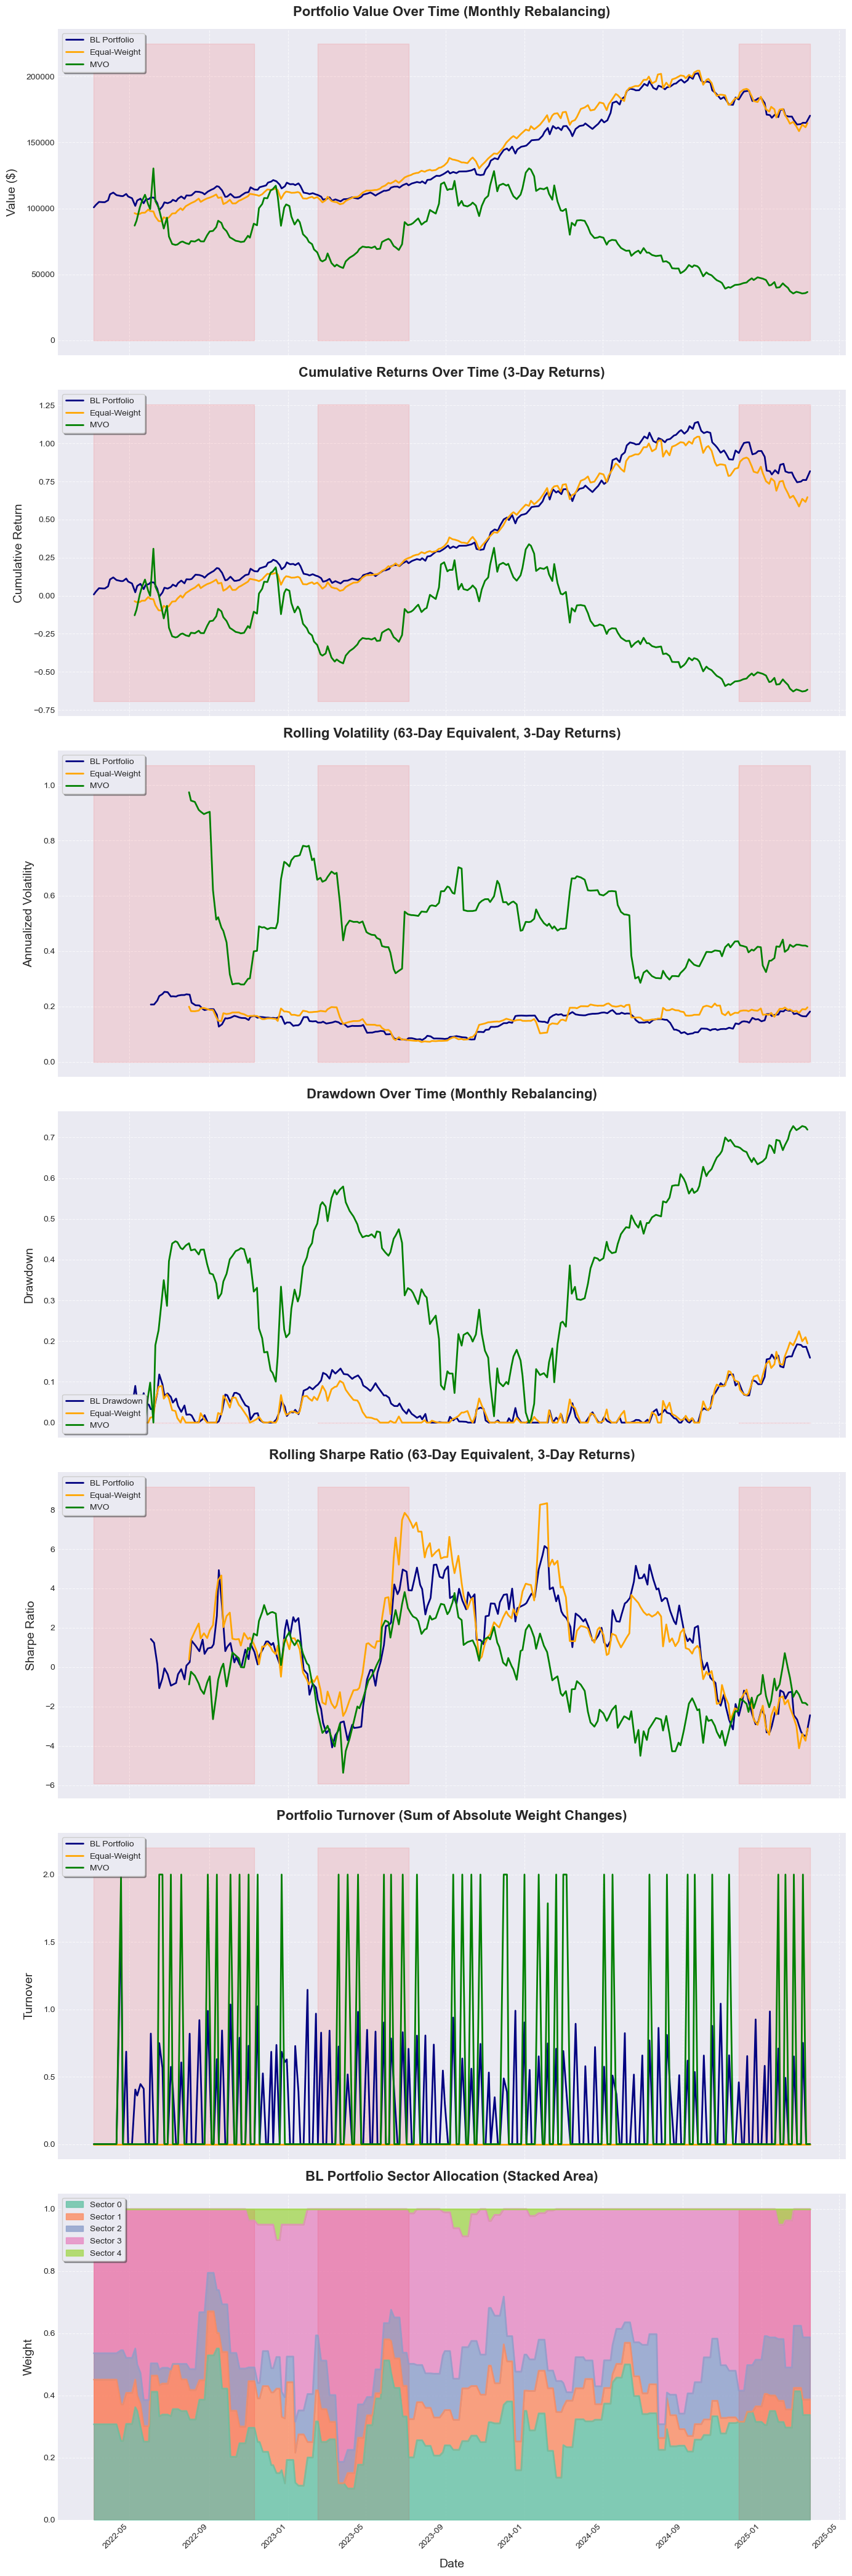

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Ensure the necessary variables are defined from Cell 9a
required_vars = ['portfolio_value_series', 'equal_portfolio_value_series', 'mvo_portfolio_value_series',
                 'portfolio_returns_series', 'equal_portfolio_returns_series', 'mvo_portfolio_returns_series',
                 'weights_history', 'backtest_dates', 'full_data', 'sector_labels',
                 'risk_free_rate_3day']
for var in required_vars:
    if var not in globals():
        raise NameError(f"{var} is not defined. Please run Cell 9a to generate these variables.")

# Define market_trend_series directly in Cell 10
market_trend_series = test_factors['market_trend'].reindex(portfolio_value_series.index)

# Set a more visually appealing style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("deep")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 18,
    'axes.titlepad': 15,
    'axes.labelpad': 10,
    'lines.linewidth': 2,
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
})

# Visualizations
fig, axs = plt.subplots(7, 1, figsize=(14, 42), sharex=True)

# 1. Portfolio Value Over Time
axs[0].plot(portfolio_value_series.index, portfolio_value_series, label='BL Portfolio', color='navy')
axs[0].plot(equal_portfolio_value_series.index, equal_portfolio_value_series, label='Equal-Weight', color='orange')
axs[0].plot(mvo_portfolio_value_series.index, mvo_portfolio_value_series, label='MVO', color='green')
axs[0].set_title('Portfolio Value Over Time (Monthly Rebalancing)', fontsize=16, pad=15, fontweight='bold')
axs[0].set_ylabel('Value ($)', fontsize=14)
axs[0].legend(loc='upper left', fontsize=10, frameon=True, shadow=True)
axs[0].grid(True, linestyle='--', alpha=0.7)
axs[0].fill_between(market_trend_series.index, 0, max(portfolio_value_series.max(), equal_portfolio_value_series.max(), mvo_portfolio_value_series.max()) * 1.1, where=market_trend_series < 0, color='red', alpha=0.1, label='Bearish Market Periods')
axs[0].tick_params(axis='y', labelsize=10)
axs[0].tick_params(axis='x', labelsize=10, rotation=45)

# 2. Cumulative Returns Over Time
cumulative_returns = (1 + portfolio_returns_series).cumprod() - 1
equal_cumulative_returns = (1 + equal_portfolio_returns_series).cumprod() - 1
mvo_cumulative_returns = (1 + mvo_portfolio_returns_series).cumprod() - 1
axs[1].plot(cumulative_returns.index, cumulative_returns, label='BL Portfolio', color='navy')
axs[1].plot(equal_cumulative_returns.index, equal_cumulative_returns, label='Equal-Weight', color='orange')
axs[1].plot(mvo_cumulative_returns.index, mvo_cumulative_returns, label='MVO', color='green')
axs[1].set_title('Cumulative Returns Over Time (3-Day Returns)', fontsize=16, pad=15, fontweight='bold')
axs[1].set_ylabel('Cumulative Return', fontsize=14)
axs[1].legend(loc='upper left', fontsize=10, frameon=True, shadow=True)
axs[1].grid(True, linestyle='--', alpha=0.7)
axs[1].fill_between(market_trend_series.index, min(cumulative_returns.min(), equal_cumulative_returns.min(), mvo_cumulative_returns.min()) * 1.1, max(cumulative_returns.max(), equal_cumulative_returns.max(), mvo_cumulative_returns.max()) * 1.1, where=market_trend_series < 0, color='red', alpha=0.1)
axs[1].tick_params(axis='y', labelsize=10)
axs[1].tick_params(axis='x', labelsize=10, rotation=45)

# 3. Rolling Volatility (63-day window, adjusted for 3-day returns)
rolling_vol = portfolio_returns_series.rolling(window=21).std() * np.sqrt(252 / 3)
equal_rolling_vol = equal_portfolio_returns_series.rolling(window=21).std() * np.sqrt(252 / 3)
mvo_rolling_vol = mvo_portfolio_returns_series.rolling(window=21).std() * np.sqrt(252 / 3)
axs[2].plot(rolling_vol.index, rolling_vol, label='BL Portfolio', color='navy')
axs[2].plot(equal_rolling_vol.index, equal_rolling_vol, label='Equal-Weight', color='orange')
axs[2].plot(mvo_rolling_vol.index, mvo_rolling_vol, label='MVO', color='green')
axs[2].set_title('Rolling Volatility (63-Day Equivalent, 3-Day Returns)', fontsize=16, pad=15, fontweight='bold')
axs[2].set_ylabel('Annualized Volatility', fontsize=14)
axs[2].legend(loc='upper left', fontsize=10, frameon=True, shadow=True)
axs[2].grid(True, linestyle='--', alpha=0.7)
axs[2].fill_between(market_trend_series.index, 0, max(rolling_vol.max(), equal_rolling_vol.max(), mvo_rolling_vol.max()) * 1.1, where=market_trend_series < 0, color='red', alpha=0.1)
axs[2].tick_params(axis='y', labelsize=10)
axs[2].tick_params(axis='x', labelsize=10, rotation=45)

# 4. Drawdown Over Time
drawdown = (portfolio_value_series.cummax() - portfolio_value_series) / portfolio_value_series.cummax()
equal_drawdown = (equal_portfolio_value_series.cummax() - equal_portfolio_value_series) / equal_portfolio_value_series.cummax()
mvo_drawdown = (mvo_portfolio_value_series.cummax() - mvo_portfolio_value_series) / mvo_portfolio_value_series.cummax()
axs[3].plot(drawdown.index, drawdown, label='BL Drawdown', color='navy')
axs[3].plot(equal_drawdown.index, equal_drawdown, label='Equal-Weight', color='orange')
axs[3].plot(mvo_drawdown.index, mvo_drawdown, label='MVO', color='green')
axs[3].set_title('Drawdown Over Time (Monthly Rebalancing)', fontsize=16, pad=15, fontweight='bold')
axs[3].set_ylabel('Drawdown', fontsize=14)
axs[3].legend(loc='lower left', fontsize=10, frameon=True, shadow=True)
axs[3].grid(True, linestyle='--', alpha=0.7)
axs[3].fill_between(market_trend_series.index, min(drawdown.min(), equal_drawdown.min(), mvo_drawdown.min()) * 1.1, 0, where=market_trend_series < 0, color='red', alpha=0.1)
axs[3].tick_params(axis='y', labelsize=10)
axs[3].tick_params(axis='x', labelsize=10, rotation=45)

# 5. Rolling Sharpe Ratio (63-day window, adjusted for 3-day returns)
rolling_excess_returns = portfolio_returns_series - risk_free_rate_3day
rolling_sharpe = (rolling_excess_returns.rolling(window=21).mean() * (252 / 3)) / (rolling_excess_returns.rolling(window=21).std() * np.sqrt(252 / 3))
equal_rolling_excess = equal_portfolio_returns_series - risk_free_rate_3day
equal_rolling_sharpe = (equal_rolling_excess.rolling(window=21).mean() * (252 / 3)) / (equal_portfolio_returns_series.rolling(window=21).std() * np.sqrt(252 / 3))
mvo_rolling_excess = mvo_portfolio_returns_series - risk_free_rate_3day
mvo_rolling_sharpe = (mvo_rolling_excess.rolling(window=21).mean() * (252 / 3)) / (mvo_portfolio_returns_series.rolling(window=21).std() * np.sqrt(252 / 3))
axs[4].plot(rolling_sharpe.index, rolling_sharpe, label='BL Portfolio', color='navy')
axs[4].plot(equal_rolling_sharpe.index, equal_rolling_sharpe, label='Equal-Weight', color='orange')
axs[4].plot(mvo_rolling_sharpe.index, mvo_rolling_sharpe, label='MVO', color='green')
axs[4].set_title('Rolling Sharpe Ratio (63-Day Equivalent, 3-Day Returns)', fontsize=16, pad=15, fontweight='bold')
axs[4].set_ylabel('Sharpe Ratio', fontsize=14)
axs[4].legend(loc='upper left', fontsize=10, frameon=True, shadow=True)
axs[4].grid(True, linestyle='--', alpha=0.7)
axs[4].fill_between(market_trend_series.index, min(rolling_sharpe.min(), equal_rolling_sharpe.min(), mvo_rolling_sharpe.min()) * 1.1, max(rolling_sharpe.max(), equal_rolling_sharpe.max(), mvo_rolling_sharpe.max()) * 1.1, where=market_trend_series < 0, color='red', alpha=0.1)
axs[4].tick_params(axis='y', labelsize=10)
axs[4].tick_params(axis='x', labelsize=10, rotation=45)

# 6. Portfolio Turnover (to visualize trading activity)
# Extract rebalancing dates and weights from weights_history
rebalance_dates = [date for date, weights in weights_history]
rebalance_weights = [weights for date, weights in weights_history]

# Create weights_df with rebalancing dates
weights_df = pd.DataFrame(rebalance_weights, index=rebalance_dates, columns=full_data.columns)
weights_df = weights_df.reindex(backtest_dates, method='ffill')

# Calculate turnover for BL portfolio
bl_turnover = pd.Series(0.0, index=backtest_dates)
for i in range(1, len(backtest_dates)):
    if backtest_dates[i] in rebalance_dates:
        bl_turnover.iloc[i] = np.abs(weights_df.iloc[i] - weights_df.iloc[i-1]).sum()

# Calculate turnover for Equal-Weight portfolio (should be minimal since weights are constant)
equal_turnover = pd.Series(0.0, index=backtest_dates)
equal_weights = pd.Series(1 / len(full_data.columns), index=full_data.columns)
for i in range(1, len(backtest_dates)):
    if backtest_dates[i] in rebalance_dates:
        equal_turnover.iloc[i] = np.abs(equal_weights - equal_weights).sum()  # Should be 0

# Calculate turnover for MVO portfolio (requires recomputing MVO weights)
mvo_weights_df = pd.DataFrame(index=backtest_dates, columns=full_data.columns)
mvo_weights = pd.Series(1 / len(full_data.columns), index=full_data.columns)
for t in range(len(backtest_dates)):
    if backtest_dates[t] in rebalance_dates:
        current_date = backtest_dates[t]
        window_returns = full_data.loc[:current_date].tail(lookback)
        if len(window_returns) >= lookback:
            cov_matrix = window_returns.cov() * 252
            cov_matrix = make_positive_definite(cov_matrix, min_eigenvalue=1e-2)
            cov_matrix_daily = cov_matrix / 252
            cov_matrix_daily = cp.psd_wrap(cov_matrix_daily)
            mu = window_returns.mean() * 252
            mu = mu.values
            w_var = cp.Variable(len(window_returns.columns))
            risk = cp.quad_form(w_var, cov_matrix_daily)
            objective = cp.Maximize(mu @ w_var - 3 * risk)
            constraints = [cp.sum(w_var) == 1, w_var >= 0]
            problem = cp.Problem(objective, constraints)
            try:
                problem.solve(solver=cp.SCS)
                if problem.status != cp.OPTIMAL:
                    raise ValueError(f"MVO optimization did not converge. Status: {problem.status}")
                w_mvo = w_var.value
                w_mvo = np.maximum(w_mvo, 0)
                w_mvo = w_mvo / np.sum(w_mvo)
            except Exception as e:
                print(f"MVO optimization failed on {current_date}: {e}. Using equal weights.")
                w_mvo = np.ones(len(window_returns.columns)) / len(window_returns.columns)
            mvo_weights = pd.Series(w_mvo, index=window_returns.columns)
        mvo_weights_df.iloc[t] = mvo_weights
mvo_weights_df = mvo_weights_df.ffill()

mvo_turnover = pd.Series(0.0, index=backtest_dates)
for i in range(1, len(backtest_dates)):
    if backtest_dates[i] in rebalance_dates:
        mvo_turnover.iloc[i] = np.abs(mvo_weights_df.iloc[i] - mvo_weights_df.iloc[i-1]).sum()

# Plot turnover
axs[5].plot(bl_turnover.index, bl_turnover, label='BL Portfolio', color='navy')
axs[5].plot(equal_turnover.index, equal_turnover, label='Equal-Weight', color='orange')
axs[5].plot(mvo_turnover.index, mvo_turnover, label='MVO', color='green')
axs[5].set_title('Portfolio Turnover (Sum of Absolute Weight Changes)', fontsize=16, pad=15, fontweight='bold')
axs[5].set_ylabel('Turnover', fontsize=14)
axs[5].legend(loc='upper left', fontsize=10, frameon=True, shadow=True)
axs[5].grid(True, linestyle='--', alpha=0.7)
axs[5].fill_between(market_trend_series.index, 0, max(bl_turnover.max(), equal_turnover.max(), mvo_turnover.max()) * 1.1, where=market_trend_series < 0, color='red', alpha=0.1)
axs[5].tick_params(axis='y', labelsize=10)
axs[5].tick_params(axis='x', labelsize=10, rotation=45)

# 7. Stacked Area Plot for Sector Allocation (BL Portfolio)
sector_weights = pd.DataFrame(0.0, index=weights_df.index, columns=[f'Sector {i}' for i in range(5)])
for t in range(len(weights_df)):
    for stock in weights_df.columns:
        sector = sector_labels[weights_df.columns.get_loc(stock)]
        sector_weights.iloc[t, sector] += weights_df.iloc[t][stock]
colors = sns.color_palette("Set2", n_colors=len(sector_weights.columns))
sector_weights.plot.area(stacked=True, color=colors, alpha=0.8, ax=axs[6])
axs[6].set_title('BL Portfolio Sector Allocation (Stacked Area)', fontsize=16, pad=15, fontweight='bold')
axs[6].set_xlabel('Date', fontsize=14)
axs[6].set_ylabel('Weight', fontsize=14)
axs[6].legend(loc='upper left', fontsize=10, frameon=True, shadow=True)
axs[6].grid(True, linestyle='--', alpha=0.7)
axs[6].fill_between(market_trend_series.index, 0, 1, where=market_trend_series < 0, color='red', alpha=0.1)
axs[6].tick_params(axis='y', labelsize=10)
axs[6].tick_params(axis='x', labelsize=10, rotation=45)

plt.tight_layout()
plt.show()